## HOMEWORK 3 - Visualization + Linear Regression (R → Python Bridge)

**Raul Miranda**

**March 3, 2026**

## Part I -- Visualization (40 pts)

## SETUP

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

import statsmodels.formula.api as smf
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

## Dataset read

In [2]:
df = pd.read_csv("https://raw.githubusercontent.com/Reben80/Data201/refs/heads/main/Dataset/housing.csv")
df.head()

,listing_id,price,size,bedrooms,neighborhood,type
0,100001,145143.0,1280.741760,1.0,Suburb,Townhouse
1,100002,152251.0,1406.283113,2.0,Uptown,SingleFamily
2,100003,148251.0,4146.825713,6.0,Suburb,MultiFamily
3,100004,177711.0,3946.599818,6.0,Suburb,SingleFamily
4,100005,155269.0,1243.751760,1.0,Downtown,MultiFamily



## A. Scatterplots and Aesthetics
1.  Create a scatterplot of **size vs price**.

    -   Label axes clearly.
    -   Add a meaningful title.

2.  Recreate the plot using `color = neighborhood` (use seaborn).

3.  Use transparency (`alpha`) to reduce overplotting.

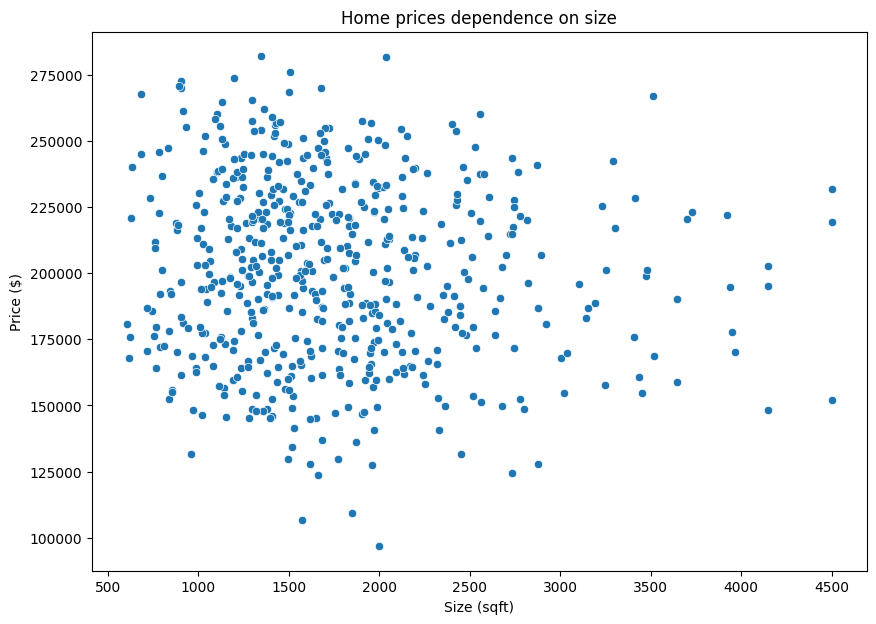

In [4]:
plt.figure(figsize=(10, 7))
sns.scatterplot(data=df, x="size", y="price")
plt.title("Home prices dependence on size")
plt.xlabel("Size (sqft)")
plt.ylabel("Price ($)")
plt.show()

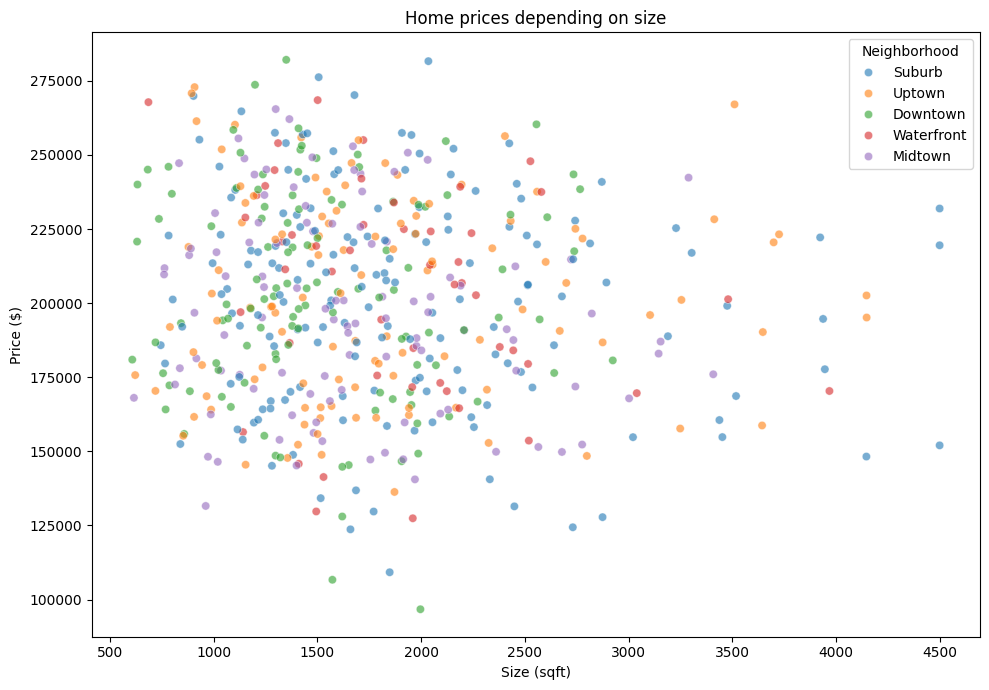

In [9]:
plt.figure(figsize=(10, 7))
sns.scatterplot(data=df, x="size", y="price", hue='neighborhood', alpha=0.6)
plt.title("Home prices depending on size")
plt.xlabel("Size (sqft)")
plt.ylabel("Price ($)")
plt.legend(
    title="Neighborhood", 
    loc="best", fontsize=10, title_fontsize=10)
plt.tight_layout()
plt.show()

### Short Answer (3--4 sentences)

-   What does seaborn automatically handle that matplotlib does not?
-   Why is transparency useful here?

Matplotlib, the basis python plotting library, is  barebones and does not handle high level actions directly with pandas dataframes, like Seaborn does. For example, Seaborn automatically extracts data from the column labels, groups them by category, and labels axes. When grouping by a category (e.g., neighborhood) seaborn assigns colors and builds the legend box. In general, it formats the plot spacing, grids, in a cleaner fashion. Seaborn can also do statistical calculations and plot regression lines, CIs, histograms, kde plots, boxplots, etc., and aggregation lines, like ggplot does. 

Transparency is useful here because there are 600 points, i.e., a relatively high density that causes overlap. Transparency helps seeing where data concentrate in clusters, and possibly let's me appreciate linearity or non-linearity visually, as well as perhaps see whether variance changes along the size axis (heteroscedasticity). In this particular dataset, there's a wide range of prices without discernable relatioship with size. Certainly there is no linearity to speak of. There is higher concentration of points at size less than 2500 sqft.  The variance changes along size, thus there is heteroscedasticity, although the dominating factor is the lack of linearity. There is no discernable pattern within the separate neighborhoods either.

## B. Small Multiples (Faceting)

Create small multiples of **size vs price**, separated by `bedrooms`.

-   Keep scales consistent.
-   Add a clear overall title.


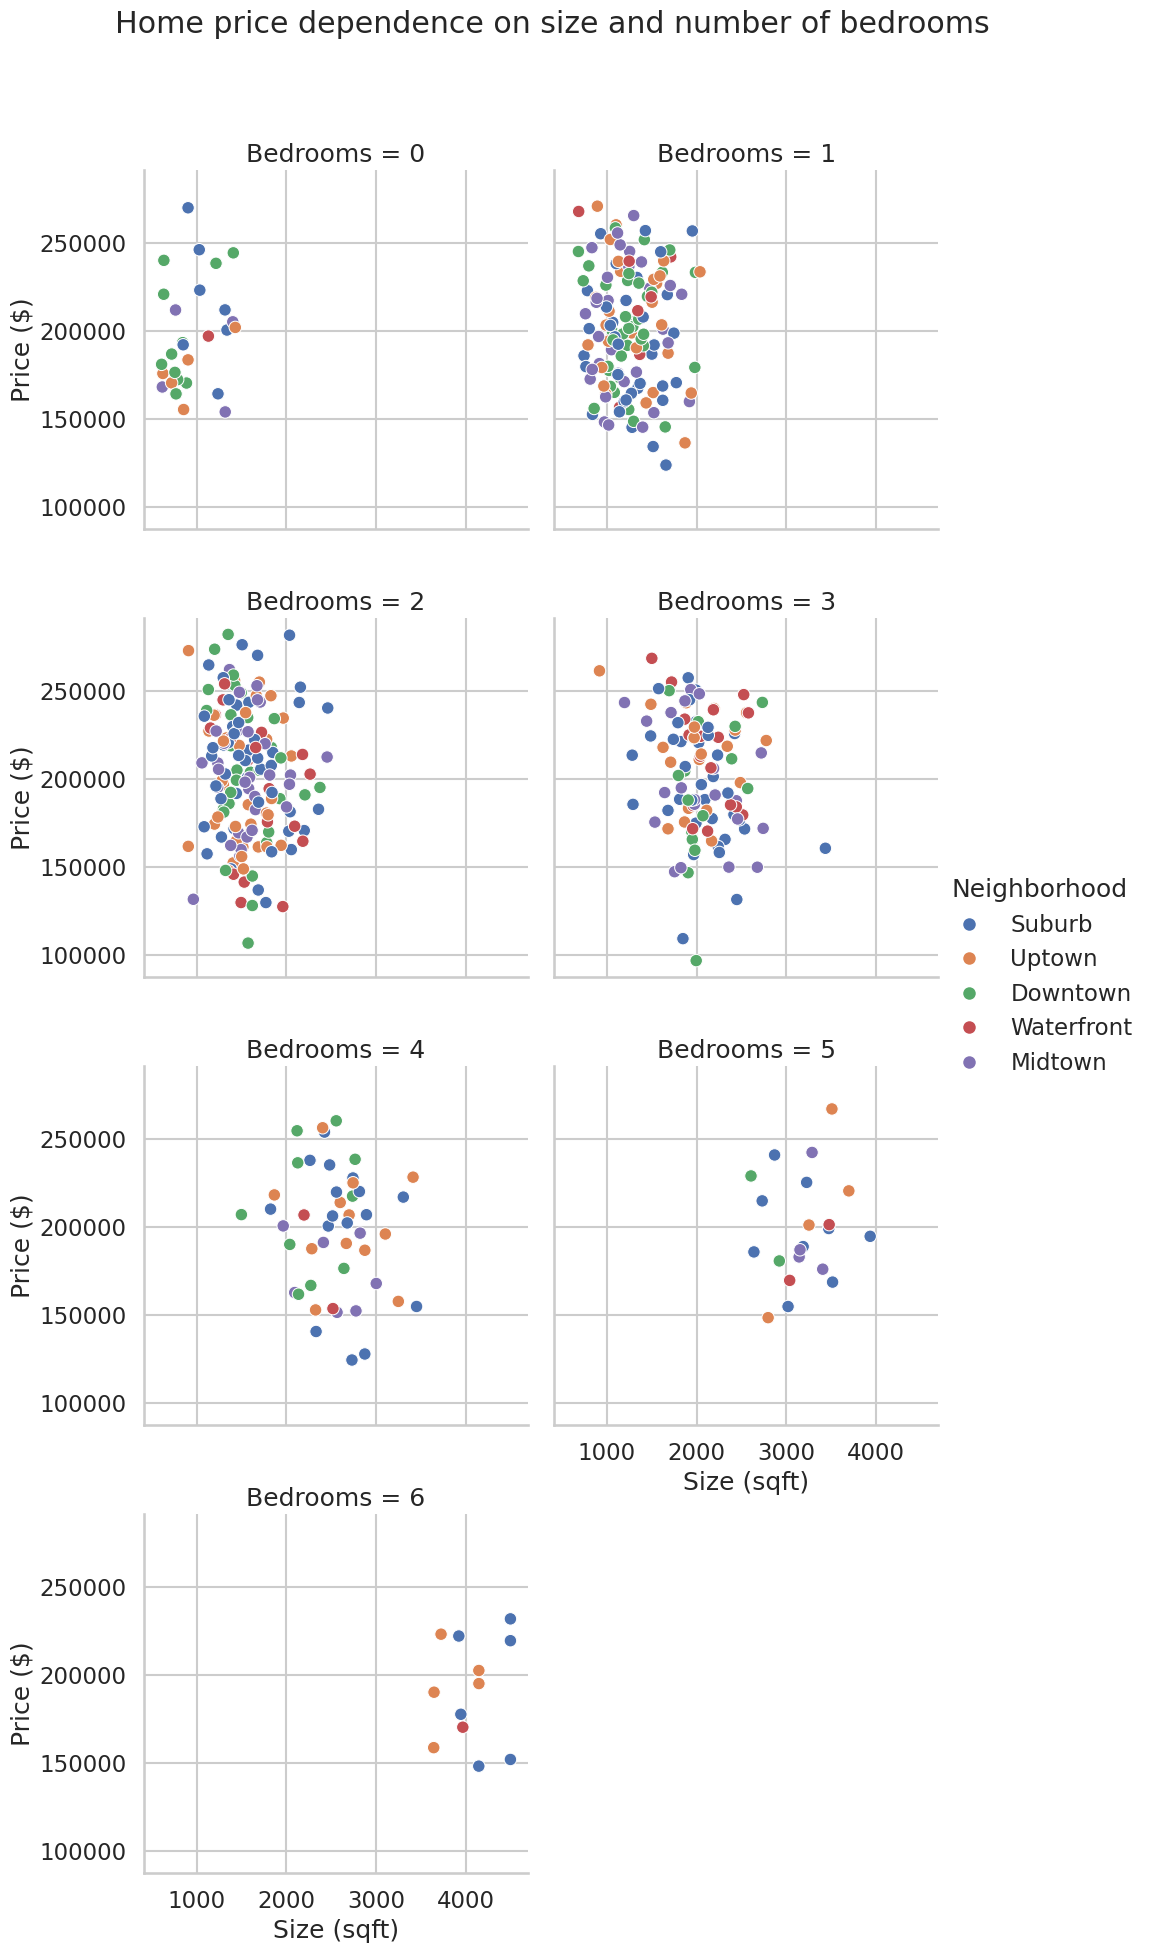

In [ ]:
gr = sns.relplot(data=df, x="size", y="price", col="bedrooms", col_wrap=2, hue="neighborhood")
gr.fig.suptitle("Home price dependence on size and number of bedrooms" )
gr.fig.subplots_adjust(top=0.9)
gr.set_titles("Bedrooms = {col_name:.0f}")
gr.set_axis_labels("Size (sqft)", "Price ($)")
gr._legend.set_title("Neighborhood")
plt.show()

### Question

Does the relationship between size and price look similar across bedroom
counts?

**Answer**
The price-size relationship looks similar across bedroom counts. There is no linear relationship of price with respect to size, regardless of neighborhood. It seems that price data does not follow the typical trend in the real estate market, where price depends on size (hence on number of bedrooms) and neighborhood. The facet-wrap shows that mean size is directly proportional to number of bedrooms.

## C. Distribution and Categorical Plots

1.  Create a histogram of `price`.
2.  Create a density plot of `price`.
3.  Create a boxplot of `price` by `neighborhood`.


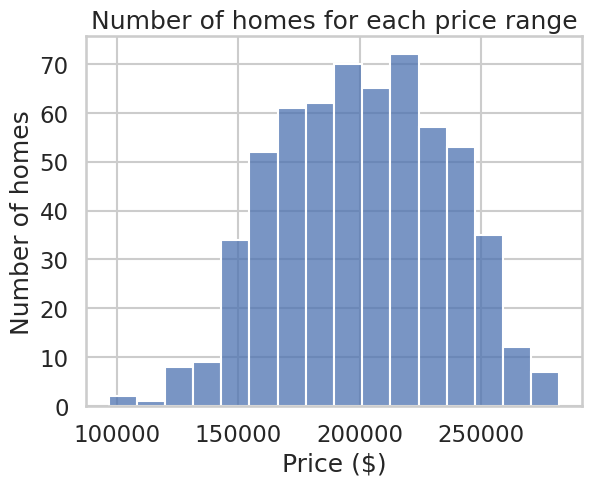

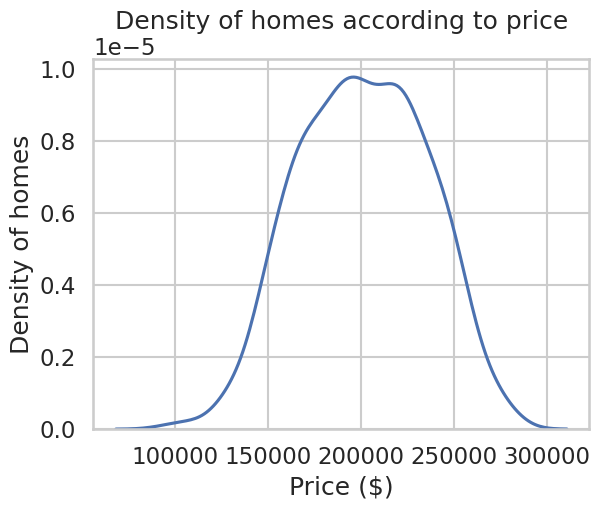

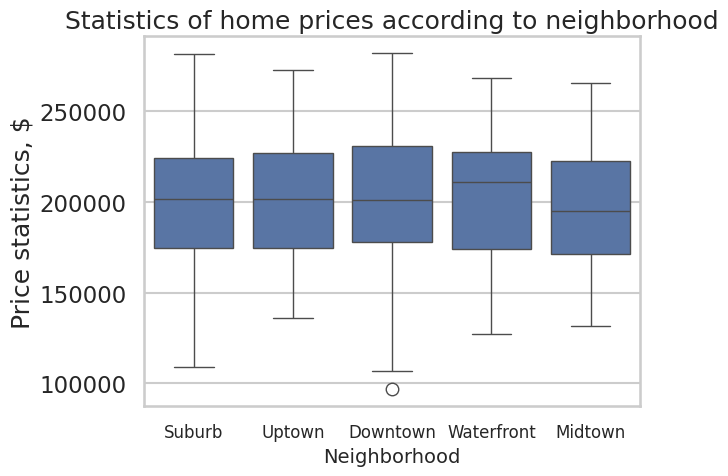

In [26]:
sns.histplot(data=df, x="price")
plt.title("Number of homes for each price range")
plt.xlabel("Price ($)")
plt.ylabel("Number of homes")
plt.show()

sns.kdeplot(data=df, x="price")
plt.title("Density of homes according to price")
plt.xlabel("Price ($)")
plt.ylabel("Density of homes")
plt.show()

ax = sns.boxplot(data=df, x="neighborhood", y="price")
plt.title("Statistics of home prices according to neighborhood")
plt.xlabel("Neighborhood", fontsize=14)
ax.tick_params(axis='x', labelsize=12)
plt.ylabel("Price statistics, $")
plt.show()


### Interpretation (short paragraph)

-   Do neighborhoods differ systematically in price?
-   What visual evidence supports your claim?

**Answer**

Price has an overall mean around $200,000 for 4 of the 5 neighborhoods, with a roughly normal distribution, except for Waterfront where the mean is around 215,000. The boxplot shows that for Waterfront, the distribtion is not normal and is positively skewed, with a heavier right tail. 

## Part II -- Linear Regression for Inference (30 pts)

## A. Multiple Regression (R → Python)

In R, the model would be:

``` r
lm(price ~ size + bedrooms + neighborhood, data = df)
```

In Python:

1.  Fit the equivalent model using `statsmodels`.
2.  Report:
    -   Coefficient estimates
    -   Standard errors
    -   R²


In [10]:
model_mlr= smf.ols(formula="price ~ size + bedrooms + C(neighborhood)", data=df).fit()
model_mlr.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  price   R-squared:                       0.017
Model:                            OLS   Adj. R-squared:                  0.005
Method:                 Least Squares   F-statistic:                     1.460
Date:                Tue, 03 Mar 2026   Prob (F-statistic):              0.190
Time:                        12:37:35   Log-Likelihood:                -6212.8
No. Observations:                 524   AIC:                         1.244e+04
Df Residuals:                     517   BIC:                         1.247e+04
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
=================================================================================================
                                    coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------------
Intercept                      2.112e+05   4925.106     42.872      0.000    2.01e+05    2.21e+05
C(neighborhood)[T.Midtown]    -4236.1877   4809.529     -0.881      0.379   -1.37e+04    5212.435
C(neighborhood)[T.Suburb]      -562.7029   4369.989     -0.129      0.898   -9147.823    8022.417
C(neighborhood)[T.Uptown]      1311.1025   4727.959      0.277      0.782   -7977.272    1.06e+04
C(neighborhood)[T.Waterfront]  3001.3355   5984.299      0.502      0.616   -8755.198    1.48e+04
size                            -10.9345      4.210     -2.597      0.010     -19.205      -2.664
bedrooms                       4372.2643   2262.445      1.933      0.054     -72.453    8816.981
==============================================================================
Omnibus:                       12.814   Durbin-Watson:                   0.699
Prob(Omnibus):                  0.002   Jarque-Bera (JB):                7.598
Skew:                          -0.114   Prob(JB):                       0.0224
Kurtosis:                       2.456   Cond. No.                     1.05e+04
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 1.05e+04. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

## B. Interpretation

Answer clearly:

1.  Interpret the coefficient on **size**, explicitly stating what is
    being held constant.
2.  Is size statistically significant? How do you know?
3.  What does R² tell us in this context?

**Answers**

1. The negative coeff of size means that each sqft added to the home size **decreases** its price by $10.9345 in the average, keeping the number of bedrooms constant and for houses in the same neighborhood. This is abnormal, as usually home prices increase with size, thus indicating abnormality in the price data.

2. Size is statistically significant because the p-value is 0.01, i.e., less than 0.05. However, see answer to 3.

3. An R2 of 0.017 and Adj.R2 of 0.005 tells us that the linear model explains about 1.7% (or 0.5%) of the variance of the data and the goodness of fit is terrible; the model has no explanatory power. This is in agreement with the figures showing no linearity between price and size. The linear model is not the correct one for this dataset. The F-statistic of 1.460 is too low; the p of 0.190>0.05, so I cannot reject the null hypothesis, confirming that the model does not explain price.

## Part III -- Prediction Workflow (20 pts)

Now switch goals: **Prediction instead of explanation**

1.  Split the data into training and test sets.
2.  Fit linear regression using scikit-learn.
3.  Compute:
    -   RMSE (on test set)
    -   R² (on test set)

In [14]:
# First we deal with the NaNs, since LinearRegression cannot handle them directly.

# Since there are NANs in size and bedrooms, I will impute them with the mean

df.isna().sum()  # 76 NaNs
df[df.isna().any(axis=1)]
df["size"] = df["size"].fillna(df["size"].mean())
df["bedrooms"] = df["bedrooms"].fillna(df["bedrooms"].mean())

In [15]:
# Dealing with CATEGORICAL variables

# Since "neighborhood" is categorical, I have to 
# replace it with n dummy variables (n=number of levels - 1).
## A simple way to generate dummy variables is pandas get_dummies. per below. 

df_encoded = pd.get_dummies(df, drop_first=True)
X = df_encoded.drop(columns="price")
y = df_encoded["price"]

In [ ]:

# now do separation of training and test sets

X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.2, 
    random_state=30)

# now do the regression

model_pred = LinearRegression()
model_pred.fit(X_train, y_train)

# now predict using the test set

y_pred = model_pred.predict(X_test)

# now evaluate accuracy

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"MSE: {mse:.3f}")
print(f"RMSE: {rmse:.3f}, which is the average error in predicted home price.")
print(f"R2 (explained variance on testing subset): {r2:.3f}")

# another check to compare R2 for training and testing sets

train_r2 = model_pred.score(X_train, y_train)
test_r2 = model_pred.score(X_test, y_test)
print("Training subset R2:", train_r2)
print("Testing subset R2:", test_r2)


MSE: 369613466.869
RMSE: 19225.334, which is the average error in predicted home price.
R2 (explained varianc on testing subset): 0.628
Training subset R2: 0.6849565527796002
Testing subset R2: 0.6284580042401753


**Short Answer**

-   Why does scikit-learn not report p-values?

--- Because scikit-learn is designed for prediction, not inference. Thus scikit-learn calculates
     coefficients and minimizes prediction error, but does not compute coefficients standard error, confidence intervals, p-values or t-statistics.

-   Which workflow would you use for:

-Explanation?
--- For explanation or inference, I use statsmodels, which does calculate p-values, confidence
         intervals, and other statistics.

-Prediction?
--- For prediction, I use scikit-learn on a training set, after train/test dataset split.

-   Why are these different goals?
--- For explanation, the goal is find the relation between variables, test hypotheses, interpret model parameters, and I need statistical significance of the model parameters and of the model.   For prediction, the goal is to accurately predict new outcomes on the basis of unseen data, thus I need cross-validation and performance metrics.


## Part IV -- Integrated Thinking (10 pts)

Create one polished figure that:

-   Shows size vs price
-   Colors by neighborhood
-   Includes a regression line
-   Has professional formatting

Then write 4--5 sentences:

-   Does the regression model match what you visually observed?
-   Did the visualization help you anticipate the model results?

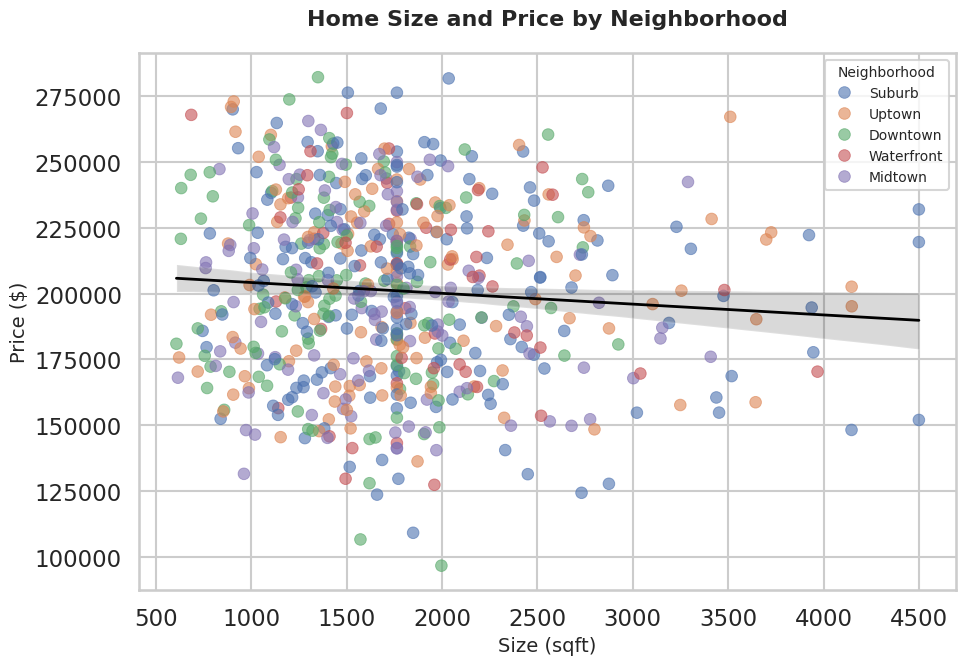

In [ ]:
# nice theme
sns.set_theme(style="whitegrid", context="talk")

# Create figure
plt.figure(figsize=(10, 7))

# Scatterplot with color by neighborhood
ax= sns.scatterplot( data=df, x="size", y="price", hue="neighborhood",
    palette="deep", alpha=0.6, s=70, edgecolor=None)

# Overall regression line
sns.regplot(data=df, x="size", y="price", scatter=False,
    color="black", line_kws={"linewidth": 2})

# Labels and title
ax.set_xlabel("Size (sqft)", fontsize=14)
ax.set_ylabel("Price ($)", fontsize=14)
ax.set_title ("Home Size and Price by Neighborhood", pad=20, fontsize=16, weight="bold")

# Legend formatting
ax.legend(title="Neighborhood", title_fontsize=10, fontsize=10, loc="best")

plt.tight_layout()
plt.show()

 **Results**: The regression model results are consistent with the visual pattern in the scatterplot. The fitted regression line shows an overall average negative dependence of price on size, which is abnormal in regular real estate markets. This is confirmed by the negative coefficient for size obtained in the OLS calculation above. The dependence on neighborhood is weak, as the lack of clustering or patterns suggest.  The visualization helped anticipate that size and neighborhood would not be strong predictors of price, as confirmed by the OLS results.

 To unscramble each neighborhood's dependence of price vs. size, let's do the following plot.

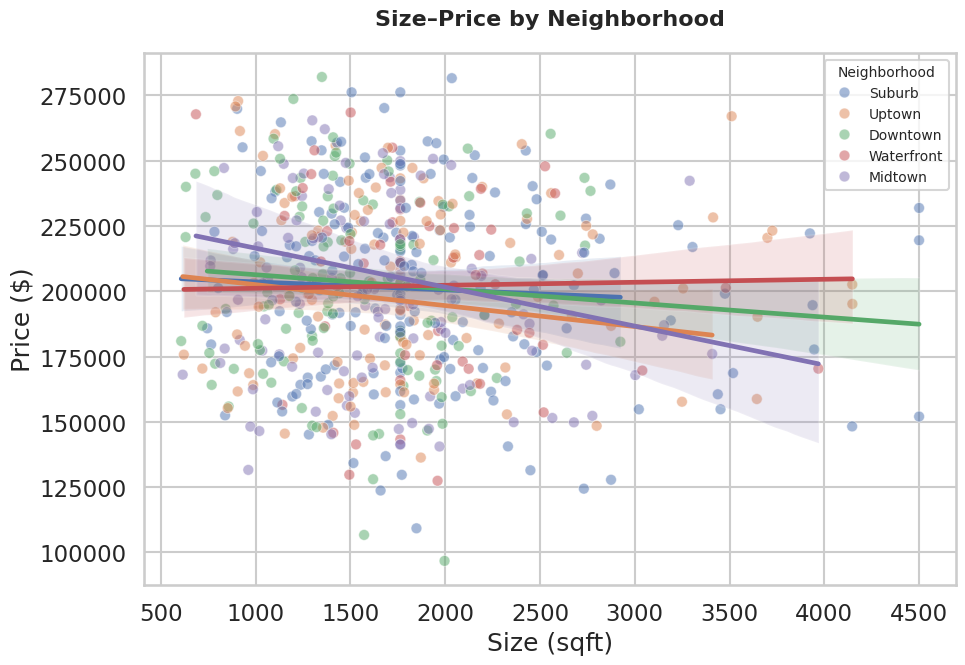

In [ ]:
# Examine price vs size dependence by neighborhood

sns.set_theme(style="whitegrid", context="talk")

# Create figure manually
fig, ax = plt.subplots(figsize=(10, 7))

# Scatterplot
sns.scatterplot(data=df, x="size", y="price", hue="neighborhood", alpha=0.5, s=60, ax=ax)

# Add separate regression lines manually for each neighborhood
for neighborhood, subset in df.groupby("neighborhood"):
    sns.regplot(data=subset, x="size", y="price", scatter=False, ax=ax, label=None)

# Labels and title
ax.set_xlabel("Size (sqft)")
ax.set_ylabel("Price ($)")
ax.set_title( "Size–Price by Neighborhood", fontsize=16, weight="bold", pad=20)

# Move legend inside plot
sns.move_legend(ax, "best", title="Neighborhood", fontsize=10, title_fontsize=10, frameon=True)

plt.tight_layout()
plt.show()

The separate regression lines show different relationships between size and price across neighborhoods. Most of the slopes are negative, showing a decrease in price with increasing size. However, Waterfront houses show a slightly positive slope, increasing from 200K up to about 215K for the largest size. The intercepts (starting price for minimum size) differ across neighborhood, with Midtown having the largest starting price. 